<a href="https://colab.research.google.com/github/DanchiTum/AI/blob/pr5/Task5_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Лабораторна робота 5. **CLASSIFICATION** 🔵/🔺

Оцінювання даної роботи буде ураховувати якість Ваших висновків та візуалізацій. При наявності ЛИШЕ коду та візуалізацій без роз'яснень, робота оцінюватися НЕ БУДЕ.  

Більшість поставлених в цій лабораторній роботі задач в майбутньому буде ставитись Вами самойстійно!

Під час виконання Вам дозволено користуватися будь-якими зручними для вас бібліотеками для візуалізації.

Оформлення коментарів повинно проводитися в текстових комірках ноутбука з використанням синтаксису [LaTeX](https://en.wikibooks.org/wiki/LaTeX/Basics) для оформлення тексту та формул.

Роботи ідентифіковані як ІДЕНТИЧНІ одразу отримують 0 балів.

# Опис вибірки "bank-additional-full"

   # Input variables:
   `bank client data:`  
   1 - **age** (numeric)  
   2 - **job** : type of job (categorical: "admin.","blue-collar","entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown")  
   3 - **marital** : marital status (categorical: "divorced","married","single","unknown"; note: "divorced" means divorced or widowed)  
   4 - **education** (categorical: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown")  
   5 - **default**: has credit in default? (categorical: "no","yes","unknown")  
   6 - **housing**: has housing loan? (categorical: "no","yes","unknown")  
   7 - **loan**: has personal loan? (categorical: "no","yes","unknown")  
   # related with the last contact of the current campaign:  
   8 - **contact**: contact communication type (categorical: "cellular","telephone")   
   9 - **month**: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  10 - **day_of_week**: last contact day of the week (categorical: "mon","tue","wed","thu","fri")  
  11 - **duration**: last contact duration, in seconds (numeric). Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.  
   # other attributes:  
  12 - **campaign**: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  13 - **pdays**: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)  
  14 - **previous**: number of contacts performed before this campaign and for this client (numeric)
  15 - **poutcome**: outcome of the previous marketing campaign (categorical: "failure","nonexistent","success")  
   # social and economic context attributes  
  16 - **emp.var.rate**: employment variation rate - quarterly indicator (numeric)  
  17 - **cons.price.idx**: consumer price index - monthly indicator (numeric)       
  18 - **cons.conf.idx**: consumer confidence index - monthly indicator (numeric)       
  19 - **euribor3m**: euribor 3 month rate - daily indicator (numeric)  
  20 - **nr.employed**: number of employees - quarterly indicator (numeric)  
    
   `Output variable (desired target):`  
  21 - **y** - has the client subscribed a term deposit? (binary: "yes","no")

## Імпорт необхідних бібліотек та завантаження даних

**Завдання 1** підготовка даних до опрацювання

1. завантажте вибірку `bank-additional-full.csv`;   
2. підключіть необхідні бібліотеки;  
3. вивести основну статистичну інформацію по числовим змінним;  
4. вивести розмірність датасету.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from sklearn.neighbors import KNeighborsClassifier

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
bank_data = pd.read_csv('bank-additional-full.csv', sep=';')

bank_data.describe()

print(f"Dataset dimensions: {bank_data.shape}")

Dataset dimensions: (41188, 21)


**Завдання 2** підготовка цільової змінної  

1. проаналізувати атрибути вибірки, визначити цільовий атрибут `target atribute`;
2. якщо `target atribute` є категоріальним, його необхідно перетворити в чисельний.

In [ ]:

bank_target = bank_data['y'].map({'no': 0, 'yes': 1})

print(bank_target.value_counts())
print(f"Target variable distribution: {round(bank_target.mean()*100, 2)}% positive class")

y
0    36548
1     4640
Name: count, dtype: int64
Target variable distribution: 11.27% positive class


## Аналіз змінних, які характеризують клієнтів банку:

**Завдання 3** Визначитись зі всіма атрибутами, що характреризують кліентів банку:
- виділити їх в окрему частину;
- первірити всі змінні (які унікальні значення містять атрибути)(дивись опис датасету).

In [ ]:
bank_client = bank_data[['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']]

for column in bank_client.columns:
    print(f"\nUnique values in {column}: {bank_client[column].unique()}")
    print(f"Count of unique values: {bank_client[column].nunique()}")


Unique values in age: [56 57 37 40 45 59 41 24 25 29 35 54 46 50 39 30 55 49 34 52 58 32 38 44
 42 60 53 47 51 48 33 31 43 36 28 27 26 22 23 20 21 61 19 18 70 66 76 67
 73 88 95 77 68 75 63 80 62 65 72 82 64 71 69 78 85 79 83 81 74 17 87 91
 86 98 94 84 92 89]
Count of unique values: 78

Unique values in job: ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
Count of unique values: 12

Unique values in marital: ['married' 'single' 'divorced' 'unknown']
Count of unique values: 4

Unique values in education: ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
Count of unique values: 8

Unique values in default: ['no' 'unknown' 'yes']
Count of unique values: 3

Unique values in housing: ['no' 'yes' 'unknown']
Count of unique values: 3

Unique values in loan: ['no' 'yes' 'unknown']
Count of unique values: 3


**Завдання 4** Аналіз атрибуту `Age`:  
1. Вивести максимальне та мінімальне значення;  
2. Перевірити на наявність `NaN`;  
3. Провести візуальний аналіз зміної `Age`:
    - побудувати `countplot`, `boxplot`, `distplot`;
    - перевірити розподіл по змінній `Age` на важкі хвости.

Minimum age: 17
Maximum age: 98
Number of NaN values in age: 0


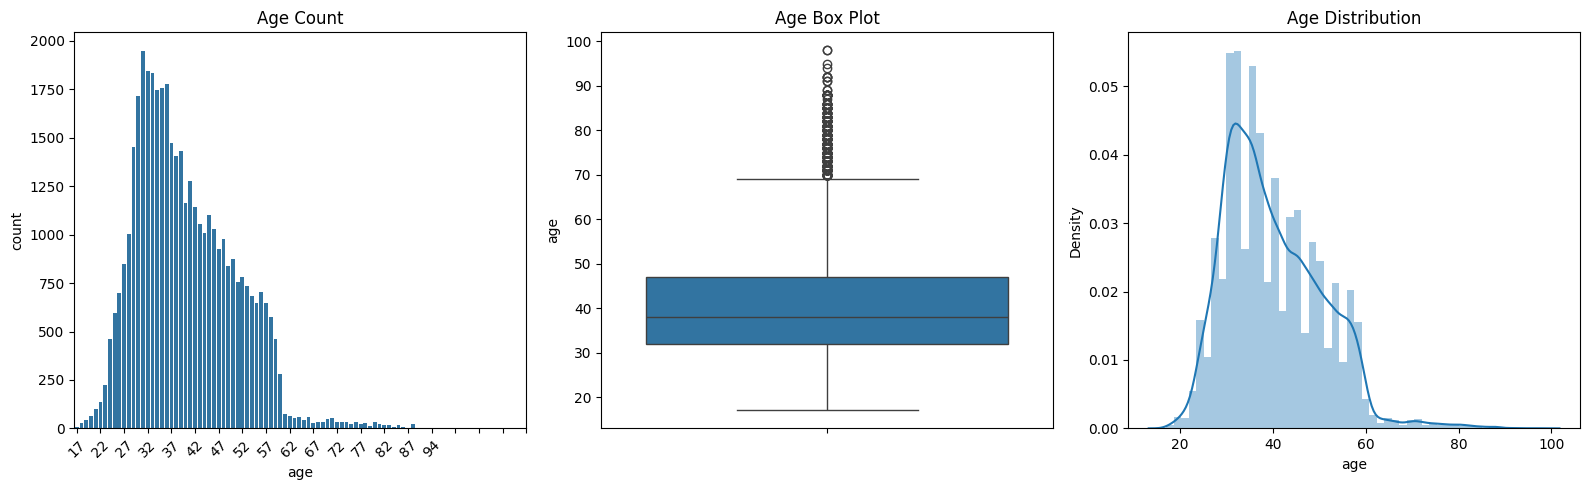

In [ ]:
print(f"Minimum age: {bank_client['age'].min()}")
print(f"Maximum age: {bank_client['age'].max()}")

print(f"Number of NaN values in age: {bank_client['age'].isna().sum()}")

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
sns.countplot(x='age', data=bank_client)
plt.title('Age Count')
plt.xticks(ticks=np.arange(0, 98
                           , step=5), rotation=45)

plt.subplot(1, 3, 2)
sns.boxplot(y='age', data=bank_client)
plt.title('Age Box Plot')

plt.subplot(1, 3, 3)
sns.distplot(bank_client['age'])
plt.title('Age Distribution')

plt.tight_layout()
plt.show()

**Висновки з 1-4 завдання (детальні)**

Вибірка складається переважно з людей віком 30–40 років.
Віковий розподіл має асиметрію, з меншою кількістю людей похилого віку.
Виявлено викиди (понад 70 років), які можуть потребувати додаткової перевірки.

**Завдання 5** Перевірити атрибут `Age` на викиди:

In [ ]:
def detect_outliers_with_interquantile_range(df: pd.DataFrame,
                                             column: str,
                                             low_percentile: int,
                                             high_percentile: int) -> pd.DataFrame:
    """
    Detecting outliers using interquantile range set manually

    df: pd.DataFrame to detect outliers
    column: target column
    low_percentile: lower bound between 0 and 100
    high_percentile: upper bound between 0 and 100

    returns: pd.DataFrame with detected outliers
    """
    sorted_data = np.sort(df[column])
    Q1 = np.percentile(sorted_data, low_percentile)
    Q3 = np.percentile(sorted_data, high_percentile)
    print('')
    print(f"Q1 {low_percentile} percentile of the given data: {Q1}")
    print('')
    print(f"Q3 {high_percentile} percentile of the given data: {Q3}")
    print('')
    print('----------------------------------------------------------')

    IQR = Q3 - Q1
    print('')
    print(f"Interquantile range: {IQR}")
    print('')
    print('----------------------------------------------------------')
    low_lim = Q1 - 1.5 * IQR
    up_lim = Q3 + 1.5 * IQR
    print('')
    print(f" Lower bound: {low_lim}")
    print('')
    print(f" Upper bound: {up_lim}")
    print('')
    print('----------------------------------------------------------')
    outliers = df[(df[column] > up_lim) | (df[column] < low_lim)]
    print('')
    print(f"Outliers in the dataset:")
    display(outliers)

    return outliers


In [ ]:
outliers = detect_outliers_with_interquantile_range(bank_client, 'age', 10, 90)


Q1 10 percentile of the given data: 28.0

Q3 90 percentile of the given data: 55.0

----------------------------------------------------------

Interquantile range: 27.0

----------------------------------------------------------

 Lower bound: -12.5

 Upper bound: 95.5

----------------------------------------------------------

Outliers in the dataset:


,age,job,marital,education,default,housing,loan
38452,98,retired,married,basic.4y,unknown,yes,no
38455,98,retired,married,basic.4y,unknown,yes,no


**Висновки з завдання 5 (детальні)**

- **10-й перцентиль (Q1) становить 28.0**, що означає, що 10% найменших значень у вибірці не перевищують цього показника.  
- **90-й перцентиль (Q3) дорівнює 55.0**, тобто 90% найменших значень у вибірці менші або рівні цьому значенню.  
- **Інтерквартильний розмах (IQR) становить 27.0**, що вказує на значну варіативність даних між 10-м та 90-м перцентилями.  
- **Визначені межі для викидів**: значення, менші за -12.5 або більші за 95.5, вважаються статистичними викидами.  

У результаті було виявлено **два записи** з віком 98 років, які виходять за верхню межу 95.5 і, відповідно, ідентифіковані як **викиди**. Це може свідчити про нетипові або рідкісні значення у вибірці.

**Завдання 6** Аналіз атрибутів `job`, `marital` та `education`:  
- Побудувати графіки розподілу даних по цим змінним.

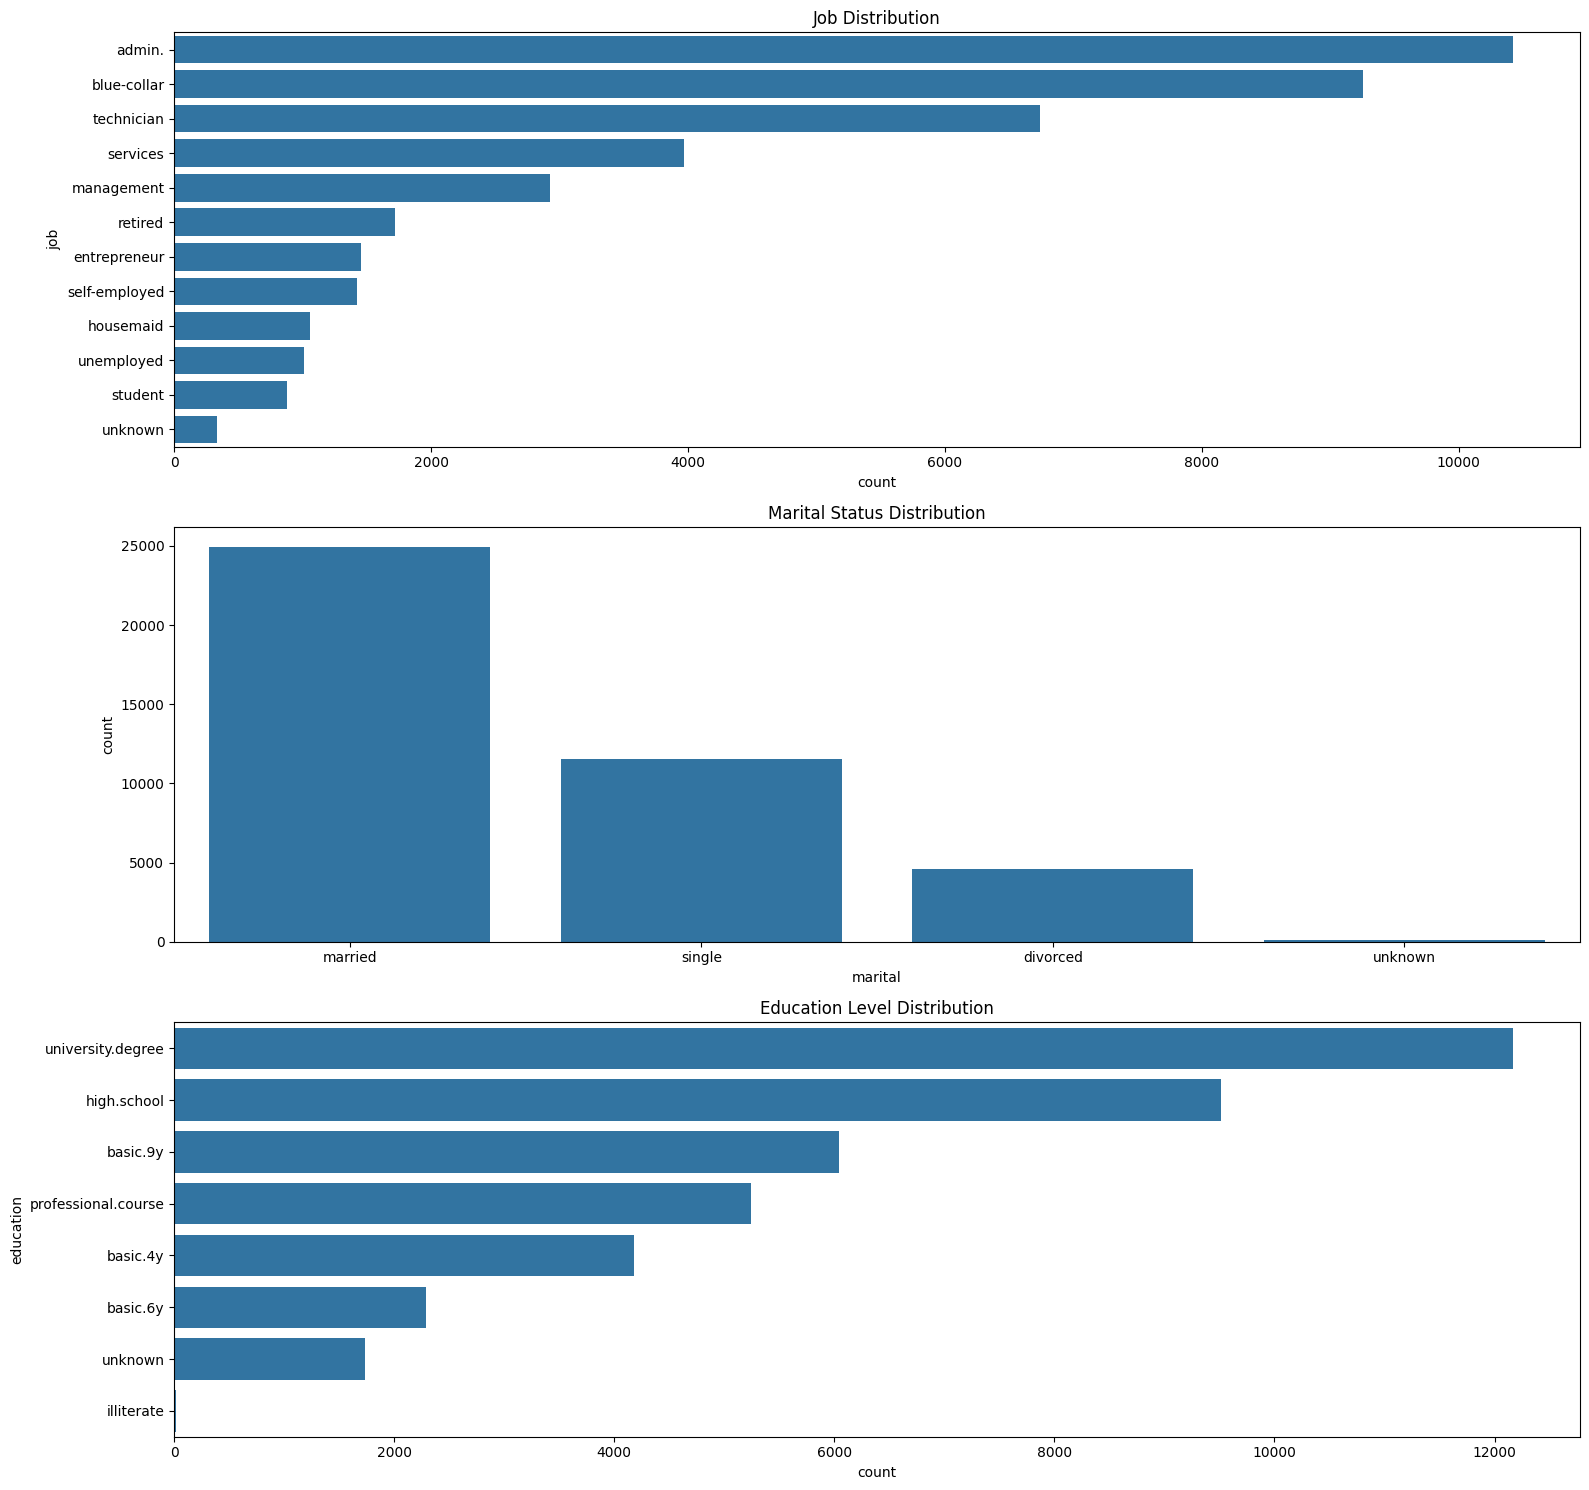

In [ ]:
plt.figure(figsize=(16, 15))

plt.subplot(3, 1, 1)
sns.countplot(y='job', data=bank_client, order=bank_client['job'].value_counts().index)
plt.title('Job Distribution')

plt.subplot(3, 1, 2)
sns.countplot(x='marital', data=bank_client)
plt.title('Marital Status Distribution')

plt.subplot(3, 1, 3)
sns.countplot(y='education', data=bank_client, order=bank_client['education'].value_counts().index)
plt.title('Education Level Distribution')

plt.tight_layout()
plt.show()

**Висновки з завдання 6 (детальні)**

1.   
2.   
3. ...

**Завдання 7** Аналіз атрибутів `default`, `housing` та `loan`:  
- Побудувати графіки розподілу даних по цим змінним.

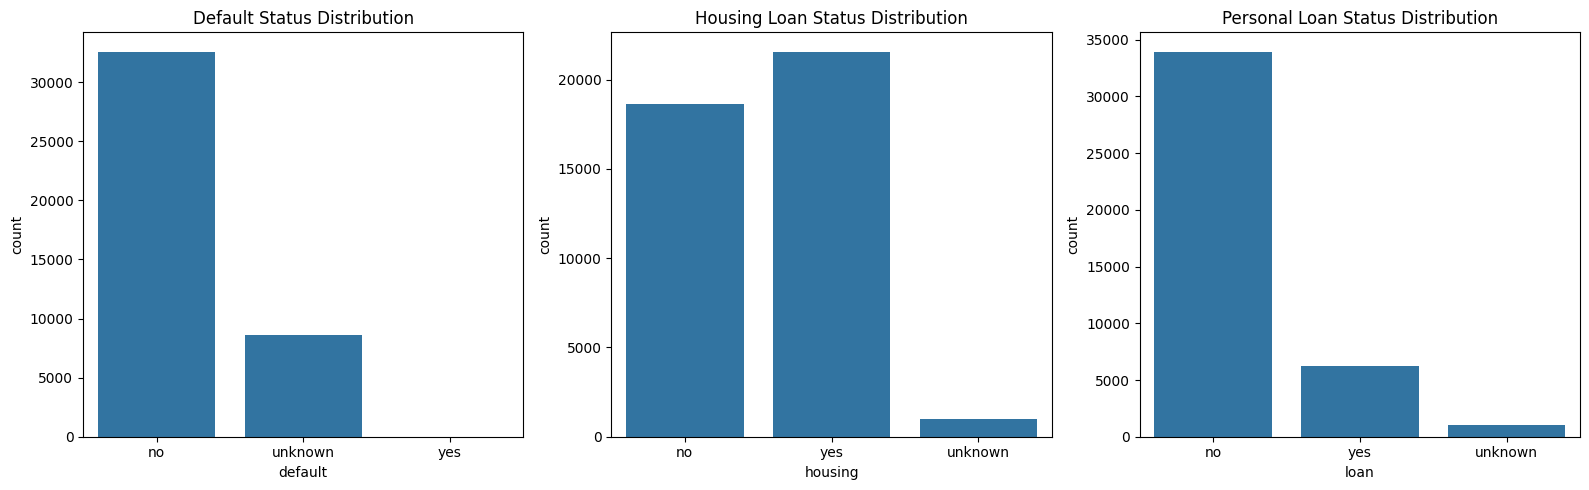

In [ ]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
sns.countplot(x='default', data=bank_client)
plt.title('Default Status Distribution')

plt.subplot(1, 3, 2)
sns.countplot(x='housing', data=bank_client)
plt.title('Housing Loan Status Distribution')

plt.subplot(1, 3, 3)
sns.countplot(x='loan', data=bank_client)
plt.title('Personal Loan Status Distribution')

plt.tight_layout()
plt.show()

**Завдання 8** Змінні **Jobs, Marital, Education, Default, Housing, Loan** трансформувати в неперервні змінні:

In [ ]:
def encode_categorical_columns(df: pd.DataFrame, categorical_cols: list) -> pd.DataFrame:
    """
    Function for encoding categorical features using LabelEncoder

    df: pd.DataFrame to encode
    categorical_cols: specified columns to encode

    returns: pd.DataFrame with encoded values
    """
    for col in categorical_cols:
        le = LabelEncoder()
        not_null = df[col][df[col].notnull()]
        df[col] = pd.Series(le.fit_transform(not_null), index=not_null.index)

    return df


In [ ]:
bank_client = encode_categorical_columns(bank_client, ['job', 'marital', 'education', 'default', 'housing',  'loan'])

**Завдання 9** Трансфомувати змінну **Age** (використовуючи її квартильні значення):




In [ ]:
def encode_age(dataframe: pd.DataFrame, age_col: str) -> pd.DataFrame:
    """
    Function for encoding age column

    df: pd.DataFrame to encode
    age_col: age col to encode
    """
    Q1 = dataframe[age_col].quantile(0.25)
    Q2 = dataframe[age_col].quantile(0.5)
    Q3 = dataframe[age_col].quantile(0.75)

    dataframe['age_group'] = 0
    dataframe.loc[dataframe[age_col] <= Q1, 'age_group'] = 0
    dataframe.loc[(dataframe[age_col] > Q1) & (dataframe[age_col] <= Q2), 'age_group'] = 1
    dataframe.loc[(dataframe[age_col] > Q2) & (dataframe[age_col] <= Q3), 'age_group'] = 2
    dataframe.loc[dataframe[age_col] > Q3, 'age_group'] = 3

    dataframe = dataframe.drop(age_col, axis=1)
    dataframe = dataframe.rename(columns={'age_group': age_col})

    return dataframe



In [ ]:
bank_client = encode_age(bank_client, 'age')
print(bank_client['age'].value_counts())

age
0    11176
2    10140
1     9999
3     9873
Name: count, dtype: int64


**Висновки з завдання 9 (детальні)** перевірити як відбулося перетворення змінних

## Вибірка містить певну кількість атрибутів, які характеризують останій зв'язок кліентів з банком

**Завдання 10** Виділити в окремий датафрейм змінні, які характеризують зв'язок клієнтів з банком;
- вивести цей датафрейм;
- перевірити ці змінні на `NaN`.

In [ ]:
bank_relat = bank_data[['contact', 'month', 'day_of_week', 'duration']]

print(bank_relat.head())

print(bank_relat.isna().sum())

     contact month day_of_week  duration
0  telephone   may         mon       261
1  telephone   may         mon       149
2  telephone   may         mon       226
3  telephone   may         mon       151
4  telephone   may         mon       307
contact        0
month          0
day_of_week    0
duration       0
dtype: int64


**Завдання 11** вивести унікальні значення, які містять атрибути `contact`, `month`, `day_of_week`

In [ ]:
for col in ['contact', 'month', 'day_of_week']:
    print(f"\nUnique values in {col}: {bank_relat[col].unique()}")
    print(f"Count of unique values: {bank_relat[col].nunique()}")


Unique values in contact: ['telephone' 'cellular']
Count of unique values: 2

Unique values in month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
Count of unique values: 10

Unique values in day_of_week: ['mon' 'tue' 'wed' 'thu' 'fri']
Count of unique values: 5


# Провести аналіз змінної **Duration**

змінна ` duration` містить інформацію про тривалість останнього дзвінка, в секундах (числова). Важливе зауваження: цей атрибут сильно впливає на цільову змінну (наприклад, якщо тривалість = 0, тоді y = "ні"). Проте тривалість невідома до здійснення дзвінка. Крім того, після закінчення дзвінка y, очевидно, відомо. Таким чином, цей внесок слід включати лише для цілей порівняльних показників і відкидати, якщо метою є реалістична модель прогнозування.

**Завдання 12** Аналіз атрибуту `duration`:  

Провести візуальний аналіз зміної `duration`:  


*   побудувати  `boxplot` та `distplot`;
*   перевірити розподіл по змінній `duration` на важкі хвости.



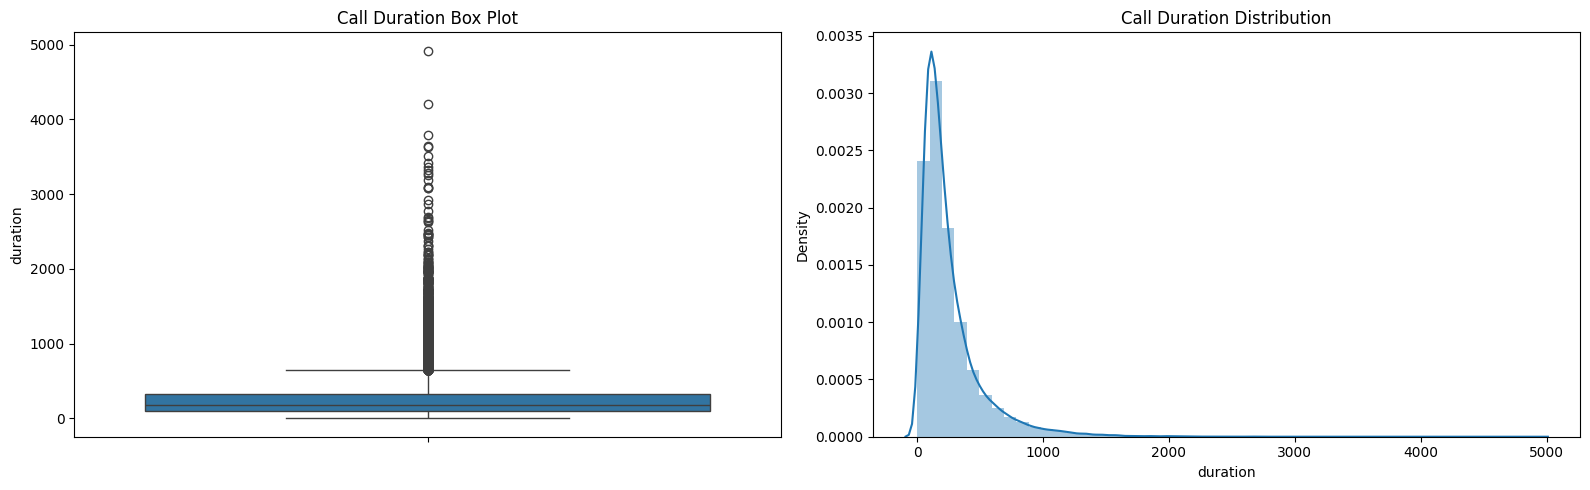

In [ ]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y='duration', data=bank_relat)
plt.title('Call Duration Box Plot')

plt.subplot(1, 2, 2)
sns.distplot(bank_relat['duration'])
plt.title('Call Duration Distribution')

plt.tight_layout()
plt.show()

**Завдання 13** Закодувати змінні Contact, Month, Day of Week (використовуйте функцію `encode_categorical_columns()`)

In [ ]:
bank_relat = encode_categorical_columns(bank_relat, ['contact', 'month', 'day_of_week'])

**Завдання 14** Трансфомувати змінну **duration**, використовуючи її квартильні значення:

In [ ]:
def encode_duration(dataframe: pd.DataFrame, duration_col: str) -> pd.DataFrame:
    """
    Function for encoding duration column

    df: pd.DataFrame to encode
    duration_col: duration col to encode
    """
    Q1 = dataframe[duration_col].quantile(0.25)
    Q2 = dataframe[duration_col].quantile(0.5)
    Q3 = dataframe[duration_col].quantile(0.75)

    dataframe['duration_group'] = 0
    dataframe.loc[dataframe[duration_col] <= Q1, 'duration_group'] = 0
    dataframe.loc[(dataframe[duration_col] > Q1) & (dataframe[duration_col] <= Q2), 'duration_group'] = 1
    dataframe.loc[(dataframe[duration_col] > Q2) & (dataframe[duration_col] <= Q3), 'duration_group'] = 2
    dataframe.loc[dataframe[duration_col] > Q3, 'duration_group'] = 3

    dataframe = dataframe.drop(duration_col, axis=1)
    dataframe = dataframe.rename(columns={'duration_group': duration_col})

    return dataframe


In [ ]:
bank_relat = encode_duration(bank_relat, 'duration')
print(bank_relat['duration'].value_counts())

duration
1    10392
0    10313
3    10286
2    10197
Name: count, dtype: int64


## Провести аналіз атрибутів **соціального та економічного контексту**

**Завдання 15** Виділити в окремий датафрейм атрибути соціального та єкономічного контексту

In [ ]:
bank_socec = bank_data[['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']]

print(bank_socec.describe())

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed
count  41188.000000    41188.000000   41188.000000  41188.000000  41188.000000
mean       0.081886       93.575664     -40.502600      3.621291   5167.035911
std        1.570960        0.578840       4.628198      1.734447     72.251528
min       -3.400000       92.201000     -50.800000      0.634000   4963.600000
25%       -1.800000       93.075000     -42.700000      1.344000   5099.100000
50%        1.100000       93.749000     -41.800000      4.857000   5191.000000
75%        1.400000       93.994000     -36.400000      4.961000   5228.100000
max        1.400000       94.767000     -26.900000      5.045000   5228.100000


**Завдання 16** Виділити в окремий датафрейм всі інші атрибути атрибути - `campaign`, `pdays`,`previous`, `poutcome`

In [ ]:
bank_other = bank_data[['campaign', 'pdays', 'previous', 'poutcome']]

print(bank_other.describe())

           campaign         pdays      previous
count  41188.000000  41188.000000  41188.000000
mean       2.567593    962.475454      0.172963
std        2.770014    186.910907      0.494901
min        1.000000      0.000000      0.000000
25%        1.000000    999.000000      0.000000
50%        2.000000    999.000000      0.000000
75%        3.000000    999.000000      0.000000
max       56.000000    999.000000      7.000000


**Завдання 17** Провести трансформацію атрибуту `poutcome`

In [ ]:
bank_other = encode_categorical_columns(bank_other, ['poutcome'])

print(bank_other['poutcome'].value_counts())

poutcome
1    35563
0     4252
2     1373
Name: count, dtype: int64


## Будування моделей класифікації

**Завдання 18** З'єднати всі отримані блоки в один датафрейм і перевірити, що він містить тільки потрібні для моделювання колонки

In [ ]:
bank_final = pd.concat([bank_client, bank_relat, bank_socec, bank_other], axis=1)

print(bank_final.columns)
print(bank_final.shape)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'age',
       'contact', 'month', 'day_of_week', 'duration', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'campaign', 'pdays', 'previous', 'poutcome'],
      dtype='object')
(41188, 20)


**Завдання 19** Провести ділення вибірки

In [ ]:
def prepare_data_for_training(X: pd.DataFrame,
                              target: pd.Series,
                              test_size: float,
                              n_splits: int,
                              random_state: int):
    """
    Function that prepares data for training. Splits the data into train and test datasets and get k-folds for cross-validation

    X: pd.DataFrame with features
    target: target pd.Series
    test_size: the size of test datasets
    n_splits: number of cross-validation splits
    random_state: random state to reproduce the same split

    returns: X_train, X_test, y_train, y_test, k_fold
    """

    X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=test_size, random_state=random_state)
    k_fold = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    return X_train, X_test, y_train, y_test, k_fold


In [ ]:
X_train, X_test, y_train, y_test, k_fold = prepare_data_for_training(bank_final, bank_target, 0.2, 10, 101)

In [ ]:
def scale_the_data(X_train: pd.DataFrame, X_test: pd.DataFrame):
    sc_X = StandardScaler()
    X_train = sc_X.fit_transform(X_train)
    X_test = sc_X.transform(X_test)
    return X_train, X_test

In [ ]:
X_train, X_test = scale_the_data(X_train, X_test)

## Логістична Регресія

In [ ]:
logmodel = LogisticRegression()
logmodel.fit(X_train, y_train)
logpred = logmodel.predict(X_test)

print(confusion_matrix(y_test, logpred))
print(f"Accuracy: {round(accuracy_score(y_test, logpred), 2) * 100}%")
LOGCV = cross_val_score(logmodel, X_test, y_test, cv=k_fold, n_jobs=1, scoring='accuracy').mean()
print(f"Cross-validation accuracy: {round(LOGCV, 4) * 100}%")

[[7110  169]
 [ 633  326]]
Accuracy: 90.0%
Cross-validation accuracy: 90.36999999999999%


## k-NN

k=1 86.80 (+/- 0.41)
k=2 89.32 (+/- 0.48)
k=3 88.99 (+/- 0.43)
k=4 89.83 (+/- 0.48)
k=5 89.77 (+/- 0.70)
k=6 90.23 (+/- 0.57)
k=7 90.11 (+/- 0.65)
k=8 90.35 (+/- 0.55)
k=9 90.32 (+/- 0.70)
k=10 90.41 (+/- 0.57)
k=11 90.40 (+/- 0.65)
k=12 90.40 (+/- 0.57)
k=13 90.44 (+/- 0.65)
k=14 90.42 (+/- 0.63)
k=15 90.49 (+/- 0.66)
k=16 90.50 (+/- 0.66)
k=17 90.53 (+/- 0.64)
k=18 90.52 (+/- 0.64)
k=19 90.53 (+/- 0.67)
k=20 90.52 (+/- 0.63)
k=21 90.55 (+/- 0.70)
k=22 90.53 (+/- 0.61)
k=23 90.53 (+/- 0.66)
k=24 90.55 (+/- 0.63)
k=25 90.56 (+/- 0.62)
The optimal number of neighbors is 25 with 90.6%


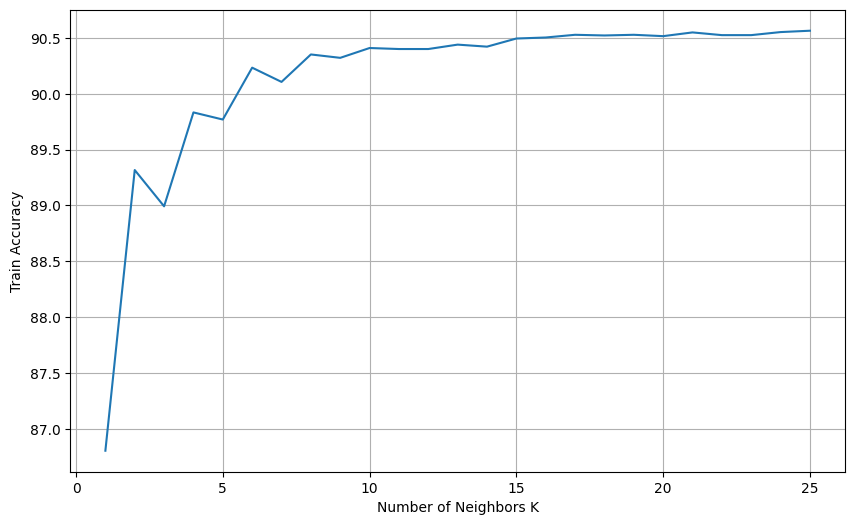

[[7147  132]
 [ 696  263]]
Accuracy: 90.0%
Cross-validation accuracy: 90.03%


In [ ]:
neighbors = np.arange(0, 25)
cv_scores = []

for k in neighbors:
    k_value = k + 1
    knn = KNeighborsClassifier(n_neighbors=k_value, weights='uniform', p=2, metric='euclidean')
    scores = model_selection.cross_val_score(knn, X_train, y_train, cv=k_fold, scoring='accuracy')
    cv_scores.append(scores.mean() * 100)
    print(f"k={k_value} {scores.mean() * 100:.2f} (+/- {scores.std() * 100:.2f})")

optimal_k = neighbors[cv_scores.index(max(cv_scores))] + 1
print(f"The optimal number of neighbors is {optimal_k} with {cv_scores[optimal_k-1]:.1f}%")

plt.figure(figsize=(10, 6))
plt.plot(neighbors + 1, cv_scores)
plt.xlabel('Number of Neighbors K')
plt.ylabel('Train Accuracy')
plt.grid(True)
plt.show()

knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)
knnpred = knn.predict(X_test)

print(confusion_matrix(y_test, knnpred))
print(f"Accuracy: {round(accuracy_score(y_test, knnpred), 2) * 100}%")
KNNCV = cross_val_score(knn, X_test, y_test, cv=k_fold, n_jobs=1, scoring='accuracy').mean()
print(f"Cross-validation accuracy: {round(KNNCV, 4) * 100}%")

## Логістична Регресія

In [ ]:
models = pd.DataFrame({
    'Models': ['Logistic Regression', 'K-Nearest Neighbors'],
    'Score': [LOGCV * 100, KNNCV * 100]
})

print(models.sort_values(by='Score', ascending=False))

                Models      Score
0  Logistic Regression  90.374149
1  K-Nearest Neighbors  90.034240


**Висновки по моделям (детальні)**

Найкращі результати дає k=25 із точністю 90.6%. Якщо вибирати занадто мале k, модель може запам’ятовувати зайві деталі й помилятися. При великих k вона краще узагальнює дані. Перевірка на тестах показала, що модель працює стабільно.
